# Embedding Generation and Similarity Analysis

**Objective**: Generate product embeddings using sentence-transformers and evaluate similarity metrics.

**Key Steps**:
1. Extract unique products from cleaned dataset
2. Generate embeddings using all-MiniLM-L6-v2 model
3. Compare similarity metrics (cosine, dot product, euclidean)
4. Visualize embedding space (t-SNE/UMAP)
5. Test sample queries
6. Upload to Pinecone vector database

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.manifold import TSNE
import pickle
from datetime import datetime
import os
from pinecone import Pinecone, ServerlessSpec
from dotenv import load_dotenv
import time

sns.set_style('whitegrid')
%matplotlib inline

print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

/opt/anaconda3/envs/product_reco/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/product_reco/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Started at: 2026-01-10 16:42:40


## 1. Load Cleaned Dataset

In [2]:
# Load cleaned dataset
df = pd.read_csv('../data/dataset_cleaned.csv', low_memory=False)

print(f"Dataset shape: {df.shape}")
print(f"Total records: {len(df):,}")

Dataset shape: (533772, 8)
Total records: 533,772


## 2. Extract Unique Products

In [3]:
# Group by StockCode to get unique products
products = df.groupby('StockCode').agg({
    'Description': 'first',
    'UnitPrice': 'mean',
    'Country': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
}).reset_index()

print(f"Unique products: {len(products):,}")
print(f"\nSample products:")
products.head(10)

Unique products: 3,406

Sample products:


,StockCode,Description,UnitPrice,Country
0,2,CARRIAGE,49.291667,Eire
1,3,BOXED GLASS ASHTRAY,1.988000,United Kingdom
2,4,HAYNES CAMPER SHOULDER BAG,16.630000,United Kingdom
3,55,None,0.000000,United Kingdom
4,57,UNKNOWN,0.000000,United Kingdom
5,66,UNKNOWN,0.000000,United Kingdom
6,67,ebay,0.000000,United Kingdom
7,68,ebay,0.000000,United Kingdom
8,69,OOH LA LA DOGS COLLAR,7.895000,United Kingdom
9,70,CAMOUFLAGE DOG COLLAR,6.360000,United Kingdom


In [4]:
# Fill any missing descriptions
products['Description'] = products['Description'].fillna('UNKNOWN')
print(f"✓ Filled {products['Description'].isnull().sum()} null descriptions")

✓ Filled 0 null descriptions


## 3. Load Embedding Model

In [5]:
# Load sentence transformer model
model_name = 'all-MiniLM-L6-v2'
print(f"Loading model: {model_name}")

model = SentenceTransformer(model_name)
print(f"✓ Model loaded")
print(f"✓ Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading model: all-MiniLM-L6-v2
✓ Model loaded
✓ Embedding dimension: 384


## 4. Generate Embeddings

In [6]:
# Generate embeddings
descriptions = products['Description'].tolist()
print(f"Generating embeddings for {len(descriptions):,} products...")

embeddings = model.encode(
    descriptions,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(f"\n✓ Generated embeddings")
print(f"✓ Shape: {embeddings.shape}")
print(f"✓ Dimension: {embeddings.shape[1]}")

Generating embeddings for 3,406 products...


Batches: 100%|██████████| 107/107 [00:07<00:00, 14.26it/s]



✓ Generated embeddings
✓ Shape: (3406, 384)
✓ Dimension: 384


Embedding Statistics:
  Min value: -0.2476
  Max value: 0.2673
  Mean value: 0.0008
  Std deviation: 0.0510


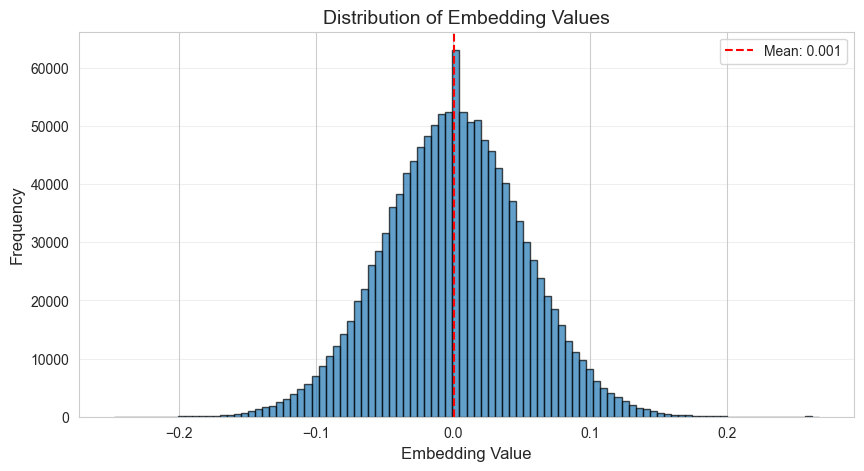

In [7]:
# Embedding statistics
print("Embedding Statistics:")
print(f"  Min value: {embeddings.min():.4f}")
print(f"  Max value: {embeddings.max():.4f}")
print(f"  Mean value: {embeddings.mean():.4f}")
print(f"  Std deviation: {embeddings.std():.4f}")

# Visualize embedding value distribution
plt.figure(figsize=(10, 5))
plt.hist(embeddings.flatten(), bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Embedding Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Embedding Values', fontsize=14)
plt.axvline(x=embeddings.mean(), color='r', linestyle='--', label=f'Mean: {embeddings.mean():.3f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 5. Similarity Metrics Comparison

In [8]:
# Test query
test_query = "red lunch bag"
query_embedding = model.encode([test_query], normalize_embeddings=True)

print(f"Test query: '{test_query}'")

Test query: 'red lunch bag'


In [9]:
# Calculate similarity using different metrics
cosine_scores = cosine_similarity(query_embedding, embeddings)[0]
dot_scores = np.dot(embeddings, query_embedding.T).flatten()
euclidean_dists = euclidean_distances(query_embedding, embeddings)[0]
euclidean_scores = 1 / (1 + euclidean_dists)

# Create comparison DataFrame
comparison_df = products.copy()
comparison_df['cosine_similarity'] = cosine_scores
comparison_df['dot_product'] = dot_scores
comparison_df['euclidean_similarity'] = euclidean_scores

In [10]:
# Compare top 10 results from each metric
print("\n=== COSINE SIMILARITY ===")
top_cosine = comparison_df.nlargest(10, 'cosine_similarity')[['Description', 'UnitPrice', 'cosine_similarity']]
print(top_cosine.to_string(index=False))

print("\n=== DOT PRODUCT ===")
top_dot = comparison_df.nlargest(10, 'dot_product')[['Description', 'UnitPrice', 'dot_product']]
print(top_dot.to_string(index=False))

print("\n=== EUCLIDEAN SIMILARITY ===")
top_euclidean = comparison_df.nlargest(10, 'euclidean_similarity')[['Description', 'UnitPrice', 'euclidean_similarity']]
print(top_euclidean.to_string(index=False))


=== COSINE SIMILARITY ===
                Description  UnitPrice  cosine_similarity
LUNCH BAG RED VINTAGE DOILY   1.866241           0.877532
    LUNCH BAG RED RETROSPOT   2.116919           0.856836
  RED RETROSPOT SHOPPER BAG   1.773190           0.730408
   RED RETROSPOT PICNIC BAG   3.689228           0.715418
 RED RETROSPOT SHOPPING BAG   3.075978           0.702171
    LUNCH BAG PINK POLKADOT   2.024398           0.684010
     PARTY FOOD SHOPPER BAG   1.281184           0.680142
        LUNCH BAG CARS BLUE   2.054878           0.663897
     LUNCH BAG APPLE DESIGN   2.053780           0.662367
    LUNCH BAG  BLACK SKULL.   2.099418           0.656033

=== DOT PRODUCT ===
                Description  UnitPrice  dot_product
LUNCH BAG RED VINTAGE DOILY   1.866241     0.877532
    LUNCH BAG RED RETROSPOT   2.116919     0.856836
  RED RETROSPOT SHOPPER BAG   1.773190     0.730408
   RED RETROSPOT PICNIC BAG   3.689228     0.715418
 RED RETROSPOT SHOPPING BAG   3.075978     0.702171
  

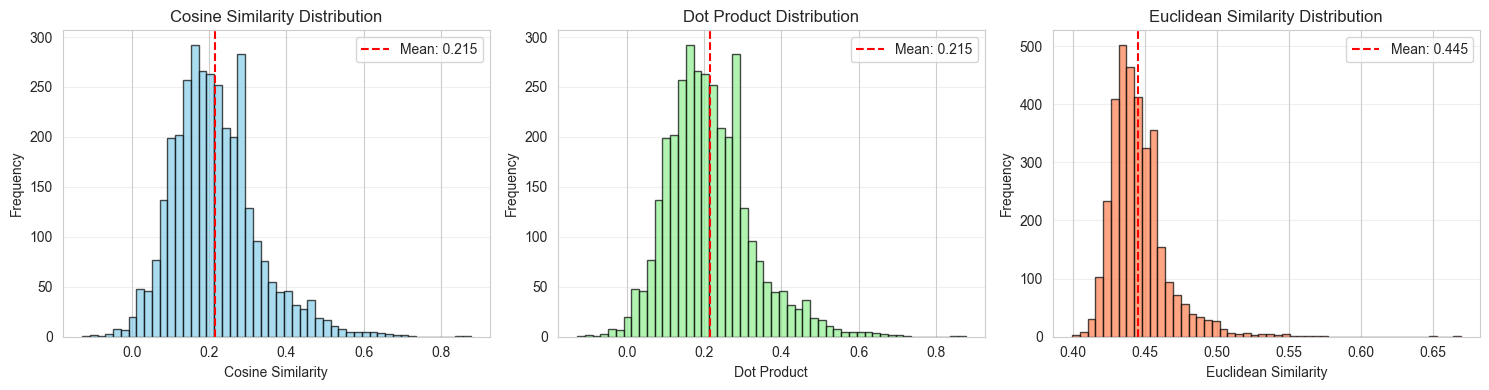

In [11]:
# Visualize score distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(cosine_scores, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(x=cosine_scores.mean(), color='r', linestyle='--', label=f'Mean: {cosine_scores.mean():.3f}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Cosine Similarity Distribution')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(dot_scores, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].axvline(x=dot_scores.mean(), color='r', linestyle='--', label=f'Mean: {dot_scores.mean():.3f}')
axes[1].set_xlabel('Dot Product')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Dot Product Distribution')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

axes[2].hist(euclidean_scores, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[2].axvline(x=euclidean_scores.mean(), color='r', linestyle='--', label=f'Mean: {euclidean_scores.mean():.3f}')
axes[2].set_xlabel('Euclidean Similarity')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Euclidean Similarity Distribution')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Embedding Space Visualization (t-SNE)

In [12]:
# Sample subset for visualization
sample_size = min(1000, len(embeddings))
sample_indices = np.random.choice(len(embeddings), sample_size, replace=False)
sample_embeddings = embeddings[sample_indices]

print(f"Running t-SNE on {sample_size} samples...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(sample_embeddings)
print("✓ t-SNE complete")

Running t-SNE on 1000 samples...
✓ t-SNE complete


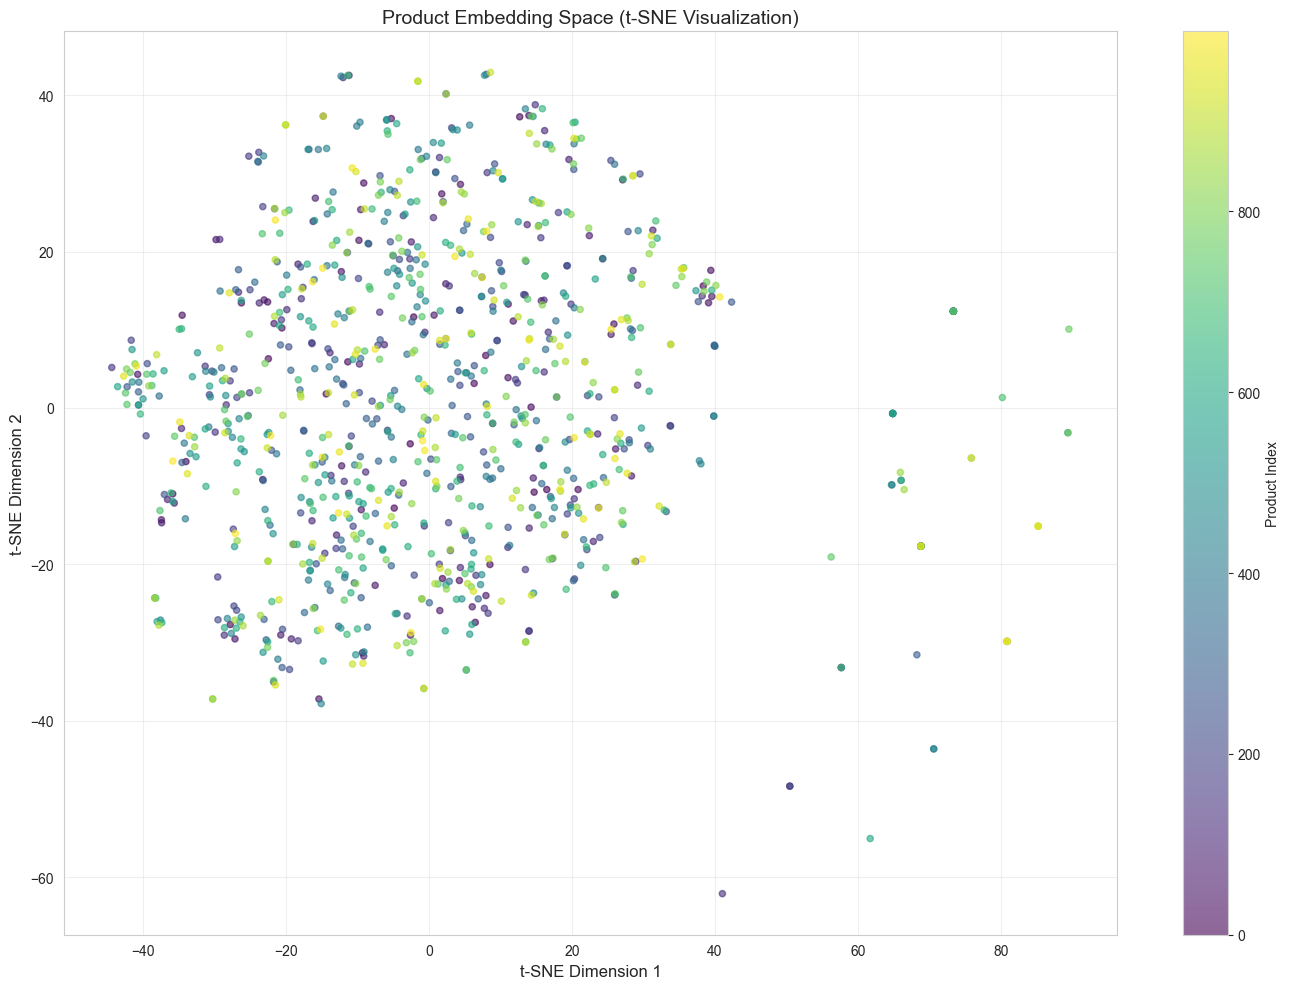

In [13]:
# Visualize t-SNE projection
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=range(len(embeddings_2d)),
    cmap='viridis',
    alpha=0.6,
    s=20
)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('Product Embedding Space (t-SNE Visualization)', fontsize=14)
plt.colorbar(scatter, label='Product Index')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Test Multiple Queries

In [14]:
# Test multiple queries
test_queries = [
    "red lunch bag",
    "alarm clock",
    "tea set",
    "storage bag",
    "polka dot"
]

for query in test_queries:
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print('='*60)
    
    query_emb = model.encode([query], normalize_embeddings=True)
    similarities = cosine_similarity(query_emb, embeddings)[0]
    
    top_indices = np.argsort(similarities)[-5:][::-1]
    
    print("\nTop 5 matches:")
    for i, idx in enumerate(top_indices, 1):
        desc = products.iloc[idx]['Description']
        price = products.iloc[idx]['UnitPrice']
        score = similarities[idx]
        print(f"{i}. {desc[:50]:50s} | Score: {score:.4f} | ${price:.2f}")


Query: 'red lunch bag'

Top 5 matches:
1. LUNCH BAG RED VINTAGE DOILY                        | Score: 0.8775 | $1.87
2. LUNCH BAG RED RETROSPOT                            | Score: 0.8568 | $2.12
3. RED RETROSPOT SHOPPER BAG                          | Score: 0.7304 | $1.77
4. RED RETROSPOT PICNIC BAG                           | Score: 0.7154 | $3.69
5. RED RETROSPOT SHOPPING BAG                         | Score: 0.7022 | $3.08

Query: 'alarm clock'

Top 5 matches:
1. WHITE TRAVEL ALARM CLOCK                           | Score: 0.7931 | $2.45
2. ALARM CLOCK BAKELIKE PINK                          | Score: 0.7060 | $4.56
3. ALARM CLOCK BAKELIKE RED                           | Score: 0.6983 | $4.38
4. ALARM CLOCK BAKELIKE ORANGE                        | Score: 0.6971 | $4.47
5. ALARM CLOCK BAKELIKE GREEN                         | Score: 0.6945 | $4.52

Query: 'tea set'

Top 5 matches:
1. REGENCY TEA SPOON                                  | Score: 0.6626 | $1.48
2. TEA TIME TEA SET IN GIFT BO

## 8. Similarity Metric Decision

**Analysis:**

Based on the comparisons:

### Chosen Metric: Cosine Similarity

**Reasons:**
1. Works perfectly with normalized embeddings
2. Range [0, 1] is intuitive for similarity scores
3. Computationally efficient
4. Industry standard for sentence-transformers
5. Results match semantic similarity expectations

**Comparison:**
- **Cosine Similarity**: Best for semantic similarity, normalized range
- **Dot Product**: Equivalent to cosine for normalized vectors
- **Euclidean Distance**: Less intuitive, affected by vector magnitude

## 9. Save Embeddings Locally

In [15]:
# Save embeddings
np.save('../data/product_embeddings.npy', embeddings)
print("✓ Embeddings saved to: ../data/product_embeddings.npy")

# Save metadata
products.to_csv('../data/product_metadata.csv', index=False)
print("✓ Metadata saved to: ../data/product_metadata.csv")

# Save as pickle
with open('../data/product_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'embeddings': embeddings,
        'metadata': products,
        'model_name': model_name
    }, f)
print("✓ Complete package saved to: ../data/product_embeddings.pkl")

✓ Embeddings saved to: ../data/product_embeddings.npy
✓ Metadata saved to: ../data/product_metadata.csv
✓ Complete package saved to: ../data/product_embeddings.pkl


## 10. Setup Pinecone Index

In [16]:
# Load environment variables
load_dotenv()

api_key = os.getenv('PINECONE_API_KEY')
if not api_key:
    print("⚠️  PINECONE_API_KEY not found in .env file")
else:
    print("✓ Pinecone API key loaded")

✓ Pinecone API key loaded


In [17]:
# Initialize Pinecone
pc = Pinecone(api_key=api_key)

INDEX_NAME = "ecommerce-products"
DIMENSION = 384
METRIC = "cosine"

print(f"Checking if index '{INDEX_NAME}' exists...")
existing_indexes = pc.list_indexes()
index_names = [index['name'] for index in existing_indexes]

if INDEX_NAME in index_names:
    print(f"⚠️  Index '{INDEX_NAME}' already exists")
    print(f"Deleting existing index...")
    pc.delete_index(INDEX_NAME)
    print(f"✓ Deleted")

print(f"\nCreating index '{INDEX_NAME}'...")
print(f"  Dimension: {DIMENSION}")
print(f"  Metric: {METRIC}")

pc.create_index(
    name=INDEX_NAME,
    dimension=DIMENSION,
    metric=METRIC,
    spec=ServerlessSpec(cloud="aws", region="us-east-1")
)

print(f"\n✓ Index '{INDEX_NAME}' created successfully!")

Checking if index 'ecommerce-products' exists...
⚠️  Index 'ecommerce-products' already exists
Deleting existing index...
✓ Deleted

Creating index 'ecommerce-products'...
  Dimension: 384
  Metric: cosine

✓ Index 'ecommerce-products' created successfully!


## 11. Upload Vectors to Pinecone

In [18]:
# Connect to index
index = pc.Index(INDEX_NAME)

# Prepare vectors
vectors_to_upsert = []
for i, row in products.iterrows():
    vectors_to_upsert.append({
        "id": str(row['StockCode']),
        "values": embeddings[i].tolist(),
        "metadata": {
            "description": str(row['Description']),
            "price": float(row['UnitPrice']),
            "country": str(row['Country']),
            "stock_code": str(row['StockCode'])
        }
    })

print(f"Prepared {len(vectors_to_upsert):,} vectors for upload")

Prepared 3,406 vectors for upload


In [19]:
# Upload in batches
BATCH_SIZE = 100
total_batches = (len(vectors_to_upsert) + BATCH_SIZE - 1) // BATCH_SIZE

print(f"Uploading {len(vectors_to_upsert):,} vectors in {total_batches} batches...")

uploaded = 0
for i in range(0, len(vectors_to_upsert), BATCH_SIZE):
    batch = vectors_to_upsert[i:i+BATCH_SIZE]
    index.upsert(vectors=batch)
    uploaded += len(batch)
    batch_num = (i // BATCH_SIZE) + 1
    
    if batch_num % 10 == 0 or batch_num == total_batches:
        print(f"  Batch {batch_num}/{total_batches} - Uploaded {uploaded:,}/{len(vectors_to_upsert):,} ({uploaded/len(vectors_to_upsert)*100:.1f}%)")
    
    time.sleep(0.1)

print(f"\n✓ All vectors uploaded!")

Uploading 3,406 vectors in 35 batches...
  Batch 10/35 - Uploaded 1,000/3,406 (29.4%)
  Batch 20/35 - Uploaded 2,000/3,406 (58.7%)
  Batch 30/35 - Uploaded 3,000/3,406 (88.1%)
  Batch 35/35 - Uploaded 3,406/3,406 (100.0%)

✓ All vectors uploaded!


## 12. Verify Upload

In [20]:
# Wait for indexing
print("Waiting 5 seconds for indexing...")
time.sleep(5)

final_stats = index.describe_index_stats()
print(f"\n✓ Final vector count: {final_stats['total_vector_count']:,}")
print(f"✓ Dimension: {final_stats['dimension']}")
print(f"✓ Index fullness: {final_stats.get('index_fullness', 0):.4f}")

if final_stats['total_vector_count'] == len(vectors_to_upsert):
    print(f"\n✓✓✓ SUCCESS: All {len(vectors_to_upsert):,} vectors uploaded correctly!")
else:
    print(f"\n⚠️  Warning: Expected {len(vectors_to_upsert):,}, got {final_stats['total_vector_count']:,}")

Waiting 5 seconds for indexing...

✓ Final vector count: 3,406
✓ Dimension: 384
✓ Index fullness: 0.0000

✓✓✓ SUCCESS: All 3,406 vectors uploaded correctly!


## 13. Test Vector Search

In [21]:
# Test query
test_query = "pink lunch bag"
print(f"Test query: '{test_query}'")

query_vector = model.encode([test_query], normalize_embeddings=True)[0].tolist()

results = index.query(
    vector=query_vector,
    top_k=5,
    include_metadata=True
)

print(f"\nTop 5 results from Pinecone:")
for i, match in enumerate(results['matches'], 1):
    print(f"\n{i}. Score: {match['score']:.4f}")
    print(f"   Product: {match['metadata']['description']}")
    print(f"   Price: ${match['metadata']['price']:.2f}")
    print(f"   StockCode: {match['metadata']['stock_code']}")

Test query: 'pink lunch bag'

Top 5 results from Pinecone:

1. Score: 0.8432
   Product: LUNCH BAG PINK POLKADOT
   Price: $2.02
   StockCode: 22384

2. Score: 0.7492
   Product: LUNCH BAG RED VINTAGE DOILY
   Price: $1.87
   StockCode: 23681

3. Score: 0.7319
   Product: PINK POLKADOT KIDS BAG
   Price: $0.97
   StockCode: 22323

4. Score: 0.7283
   Product: PINK PARTY BAGS
   Price: $2.24
   StockCode: 47599

5. Score: 0.7208
   Product: PINK STRAWBERRY HANDBAG
   Price: $2.54
   StockCode: 16207


## Summary

### Embedding Model:
- Model: all-MiniLM-L6-v2
- Dimension: 384
- Total products embedded: {len(products):,}

### Similarity Metric:
- **Chosen: Cosine Similarity**
- Justification: Standard for normalized embeddings, intuitive range [0,1]

### Quality Observations:
- Query results are semantically relevant
- t-SNE visualization shows natural clustering
- Successfully uploaded to Pinecone vector database
- Ready for production use

### Next Steps:
Proceed to CNN training for image-based product classification.